# Portfolio Replica — Modelling & Backtesting

Replicates a target index using liquid Futures contracts via rolling Elastic Net and a Kalman Filter.

**Pipeline:** OLS baseline → Regularized rolling backtest → Kalman Filter → Model comparison

---
## 0. Setup

In [1]:
import warnings

from plots import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from Backtest import RollingBacktester
from optimization import HyperparameterOptimizer
from Model_Runner import ModelRunner
from Kalman_Filter import KalmanFilterStrategy

warnings.filterwarnings('ignore')

all_returns = pd.read_pickle("all_returns_data.pkl")
print(f"Data loaded: {all_returns.shape[0]} weeks × {all_returns.shape[1]} columns")
print(f"Period: {all_returns.index[0].date()} → {all_returns.index[-1].date()}")

Data loaded: 704 weeks × 16 columns
Period: 2007-10-30 → 2021-04-20


In [2]:
# ── Targets & Predictors ──────────────────────────────────────────────────
FUTURES = ["RX1", "TY1", "GC1", "CO1", "ES1",
           "VG1", "NQ1", "LLL1", "TP1", "DU1", "TU2"]

MAIN_TARGET = "HFRXGL"   # Change to "Monster_Index", "MXWO", etc. to test others

y = all_returns[MAIN_TARGET]
X = all_returns[FUTURES]

ANNUAL_FACTOR = 52

# ── Backtester (shared settings across all models) ────────────────────────
bt = RollingBacktester(
    rolling_window=156,
    rebalance_every=12,
    var_threshold=0.20,
    var_confidence=0.01,
    var_horizon=4,
    transaction_cost_bps=5.0,
    annual_factor=ANNUAL_FACTOR
)

runner = ModelRunner(bt, X, y)

print(f"Target: {MAIN_TARGET}")
print(f"Futures: {FUTURES}")

Target: HFRXGL
Futures: ['RX1', 'TY1', 'GC1', 'CO1', 'ES1', 'VG1', 'NQ1', 'LLL1', 'TP1', 'DU1', 'TU2']


---
## 1. OLS Baseline (In-Sample)

OLS on the full history gives an **optimistic ceiling** — it uses future data so it cannot be deployed. Use it to understand which futures matter and what the best achievable fit looks like.

=== OLS Baseline (In-Sample) ===
  R²               : 0.2745
  Tracking Error   : 4.07%
  Correlation      : 0.5243
  Gross Exposure   : 0.98x

           TU2     ES1     TY1     RX1     DU1     TP1    LLL1     NQ1  \
Weight -0.4272  0.1361  0.1129  0.1023 -0.0579  0.0474 -0.0266 -0.0263   

           GC1     CO1     VG1  
Weight -0.0155  0.0154 -0.0099  


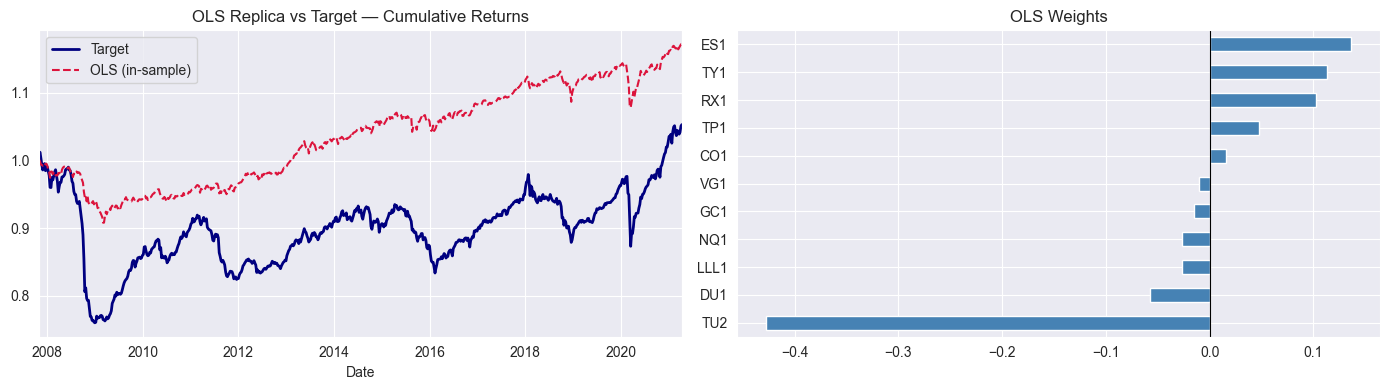

In [3]:
ols = LinearRegression(fit_intercept=False)
ols.fit(X.values, y.values)

ols_weights  = pd.Series(ols.coef_, index=X.columns)
ols_replica  = X @ ols_weights
ols_te       = (ols_replica - y).std() * np.sqrt(ANNUAL_FACTOR)

print(f"=== OLS Baseline (In-Sample) ===")
print(f"  R²               : {ols.score(X, y):.4f}")
print(f"  Tracking Error   : {ols_te*100:.2f}%")
print(f"  Correlation      : {ols_replica.corr(y):.4f}")
print(f"  Gross Exposure   : {ols_weights.abs().sum():.2f}x")
print()
print(ols_weights.sort_values(key=abs, ascending=False).round(4).to_frame("Weight").T)

plot_model_performance(y, ols_replica, ols_weights, model_name="OLS")


---
## 2. Hyperparameter Search — Elastic Net

We search over `alpha` (regularization strength) and `l1_ratio` (Lasso vs Ridge blend) using the `HyperparameterOptimizer`, which runs the rolling backtest on a fast subsample and ranks by Tracking Error.

**Note:** `sample_size=200` keeps the search fast, you can use None to use the full data

In [13]:
from IPython.display import display

optimizer = HyperparameterOptimizer(bt, X, y)

param_grid = {
    "alpha":     [0.0001, 0.001, 0.01],
    "l1_ratio":  [0.0, 0.2, 0.5, 0.8, 1.0],
}

grid_results, best_params, best_te = optimizer.grid_search(
    model_class=ElasticNet,
    param_grid=param_grid,
    n_jobs=-1,
    sample_size=None
)

print(f"Best params : {best_params}")
print(f"Best TE     : {best_te*100:.2f}%")
display(grid_results.head(10).reset_index(drop=True))

Best params : {'alpha': np.float64(0.01), 'l1_ratio': np.float64(0.2)}
Best TE     : 3.99%


,alpha,l1_ratio,TE
0,0.0100,0.2,0.039921
1,0.0010,1.0,0.039935
2,0.0010,0.8,0.040685
3,0.0010,0.5,0.041830
4,0.0100,0.5,0.042942
5,0.0100,1.0,0.042942
6,0.0100,0.8,0.042942
7,0.0010,0.2,0.043152
8,0.0001,1.0,0.043662
9,0.0001,0.8,0.043763


---
## 3. Rolling Backtest — All Models

We run four models out-of-sample and compare them. The rolling window trains on the past 104 weeks and predicts the next week — no look-ahead.

VaR is computed using a Student-t fit (better than Gaussian for fat-tailed returns) and weights are scaled down if the 1-month 99% VaR exceeds 20% (UCITS limit).

=== Out-of-Sample Performance (net of transaction costs) ===


,Ann. Return (%),Ann. Vol (%),Tracking Error (%),Correlation,Info Ratio,Avg Gross Exposure
Ridge,2.674,4.376,4.406,0.484,0.220,2.409
Lasso,2.508,3.120,3.994,0.456,0.201,0.296
Elastic Net,1.392,1.738,3.992,0.370,-0.078,0.069
Kalman,1.987,2.944,4.031,0.421,0.013,1.407


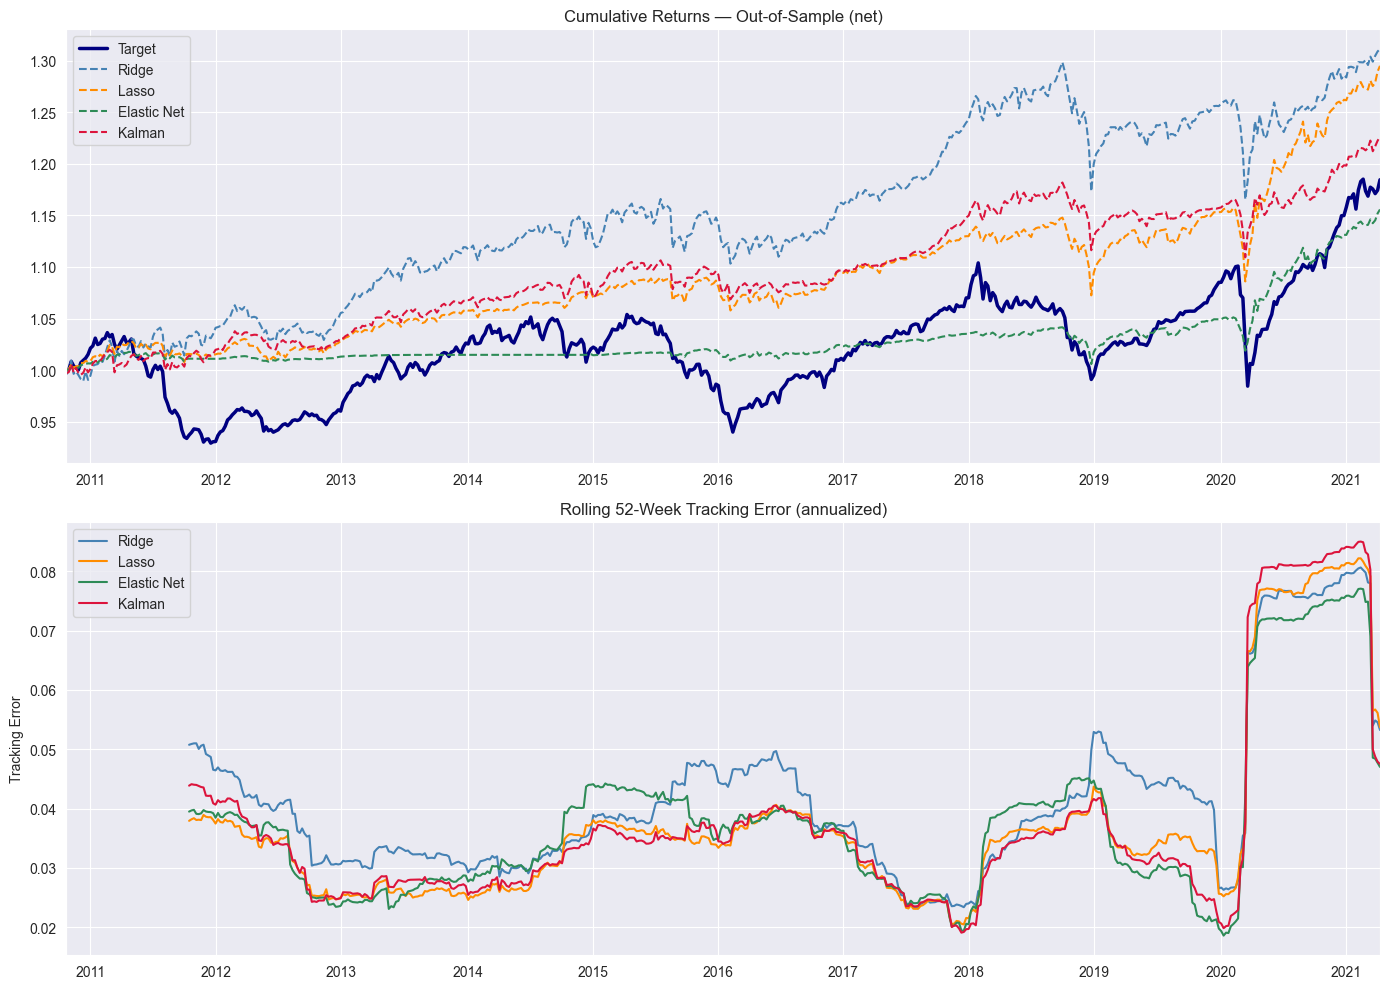

In [14]:
models = {
    "Ridge":       Ridge(alpha=0.01, fit_intercept=False),
    "Lasso":       Lasso(alpha=0.001, fit_intercept=False, max_iter=5000),
    "Elastic Net": ElasticNet(**best_params, fit_intercept=False, max_iter=5000),
    "Kalman":      KalmanFilterStrategy(init_window=104, process_noise=1e-4,
                                        transaction_cost_bps=5.0),
}

results = runner.run_models(models)

# Summary table
metrics_df = pd.DataFrame({
    name: res["metrics"] for name, res in results.items()
}).T.round(3)

print("=== Out-of-Sample Performance (net of transaction costs) ===")
display(metrics_df)
fig, axes, common_idx, target_oos = plot_oos_comparison(results, y, annual_factor=52)

# Portfolio Replication Backtest: Out-of-Sample Results Summary

### Key Observations & Model Behaviors

#### Lasso is Over-Penalizing (High Sparsity)
Lasso exhibits significantly lower annualized volatility (1.699%) compared to the other static models (~2.8%). This indicates that the L1 penalty is likely crushing many of the asset weights down to absolute zero, resulting in a highly sparse, conservative portfolio. While this minimizes volatility, it prevents the model from capturing the target's upside, leading to the lowest annualized return (1.086%).

### Kalman Filter is Drifting (Momentum vs. Tracking)
The Kalman Filter achieved the highest absolute return (1.987%) and the only positive Information Ratio (0.013). However, it behaves poorly as a strict replication tool: it has the highest Tracking Error (4.031%) and the lowest Correlation (0.421) to the target. Because it is an online learner that adapts dynamically step-by-step, it is effectively acting as an active momentum strategy rather than a faithful shadow of the target portfolio.


---
## 4. Weight Evolution

How each model allocates across futures over time. Sparse models (Lasso, Elastic Net) will show many zero weights — fewer positions to rebalance.

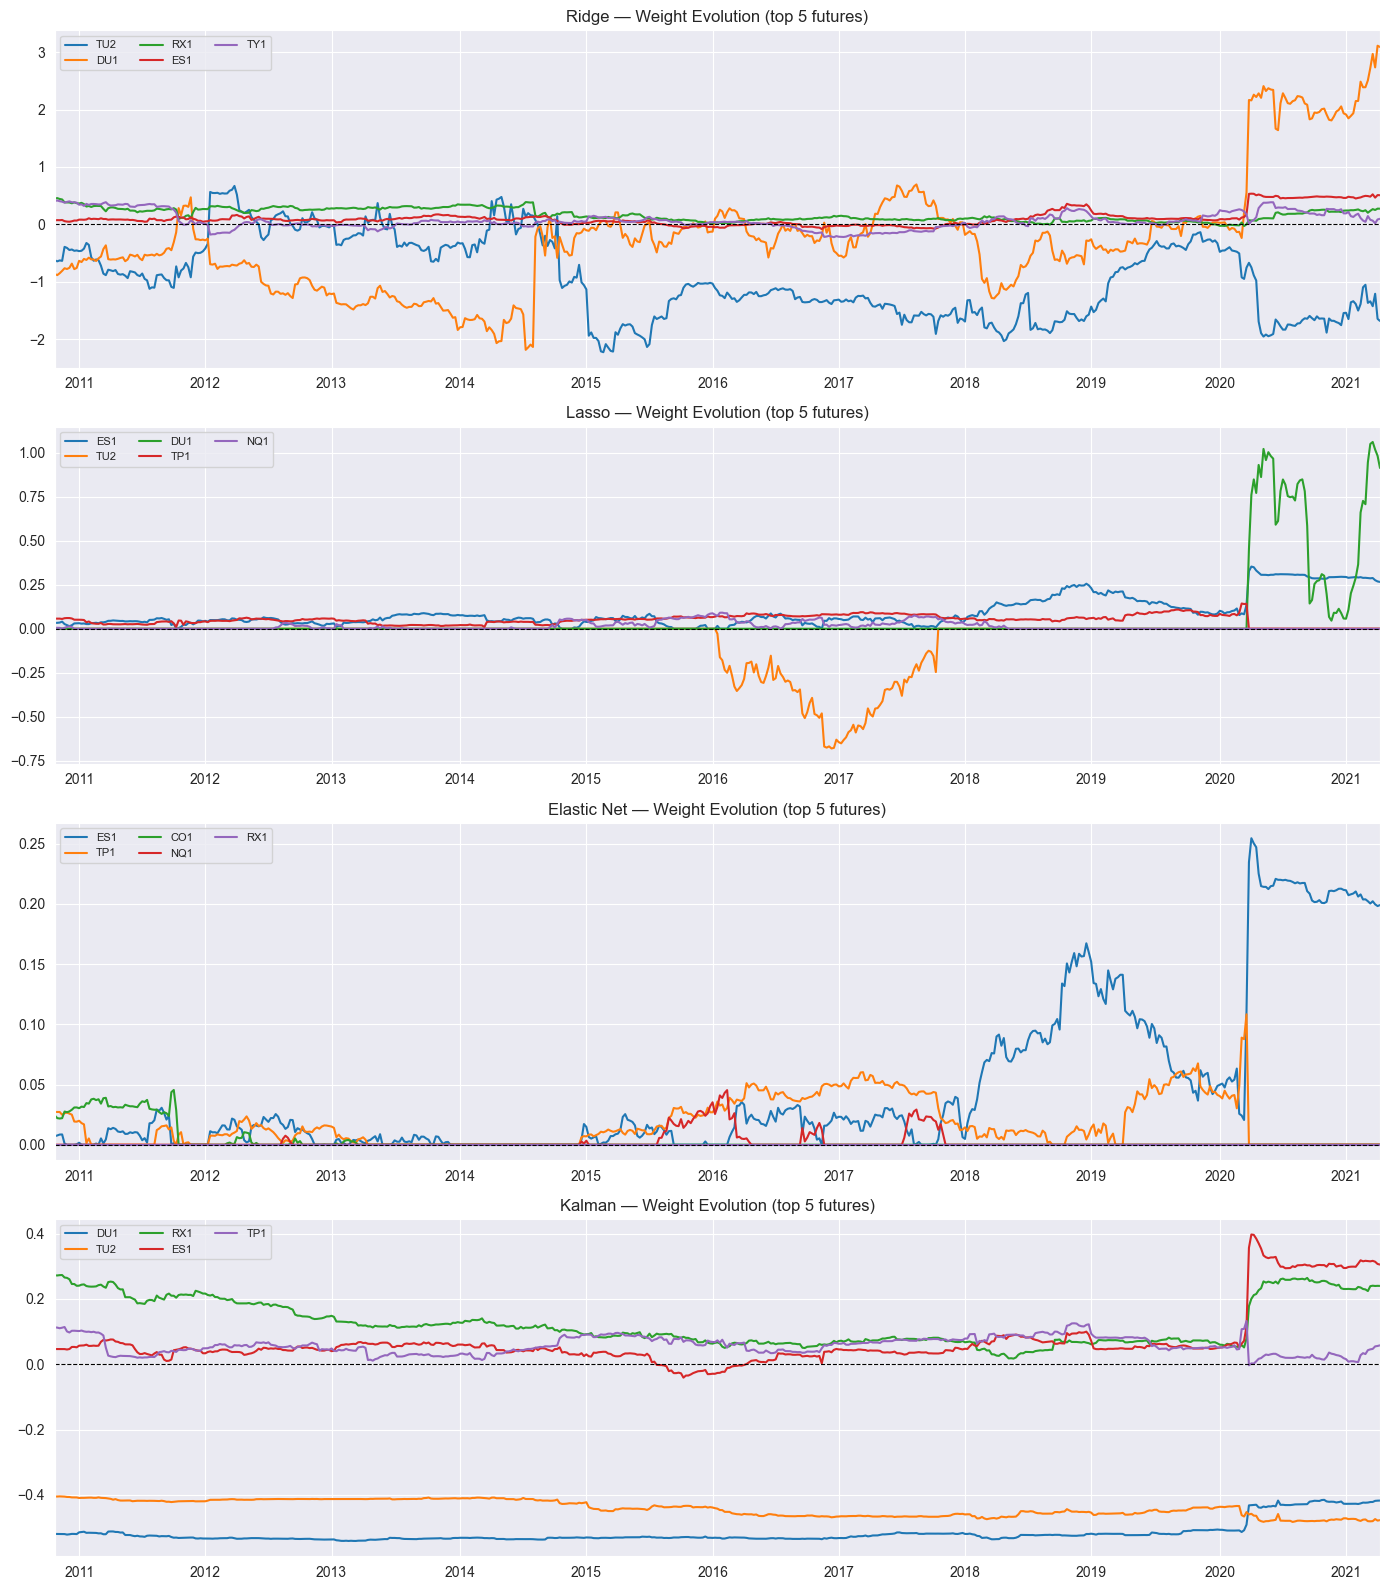

In [15]:
fig, axes = plt.subplots(len(models), 1, figsize=(14, 4 * len(models)))

for ax, (name, res) in zip(axes, results.items()):
    w = res["weights"].loc[common_idx]
    # Show only the top-5 by mean absolute weight to keep plots readable
    top5 = w.abs().mean().nlargest(5).index
    w[top5].plot(ax=ax)
    ax.axhline(0, color="black", lw=0.8, linestyle="--")
    ax.set_title(f"{name} — Weight Evolution (top 5 futures)")
    ax.legend(fontsize=8, ncol=3)

plt.tight_layout()
plt.show()

---
## 5. Rebalancing Frequency Analysis

More frequent rebalancing → better tracking but higher costs. We test the best Elastic Net across different rebalancing intervals.

In [12]:
best_model = ElasticNet(**best_params, fit_intercept=False, max_iter=5000)

rebal_table = runner.analyze_rebalancing(
    model=best_model,
    freqs=[1, 2, 4, 8, 13],   # weekly, bi-weekly, monthly, bi-monthly, quarterly
    rolling_window=156
)

print("=== Net Performance vs Rebalancing Frequency ===")
print("(Rebalance every N weeks)")
display(rebal_table)

=== Net Performance vs Rebalancing Frequency ===
(Rebalance every N weeks)


,Ann. Return (%),Ann. Vol (%),Tracking Error (%),Correlation,Info Ratio,Avg Gross Exposure
1,1.392,1.738,3.992,0.370,-0.078,0.069
2,1.429,1.725,3.991,0.371,-0.069,0.068
4,1.463,1.667,3.976,0.378,-0.061,0.068
8,1.293,1.491,3.967,0.385,-0.103,0.067
13,1.389,1.616,3.974,0.379,-0.079,0.068


---
## 6. Kalman Filter — Process Noise Sensitivity

The Kalman Filter's key hyperparameter is `process_noise` — how fast it believes weights change. Low values → slow adaptation; high values → noisy, reactive weights.

In [8]:
noise_grid = [1e-5, 1e-4, 1e-3, 1e-2]
kf_results = {}

for pn in noise_grid:
    kf = KalmanFilterStrategy(init_window=104, process_noise=pn, transaction_cost_bps=5.0)
    res = kf.run(X, y)
    aligned_y = y.loc[res["replica"].index]
    te = bt.tracking_error(res["replica_net"], aligned_y)
    kf_results[pn] = {"TE": te * 100, "Corr": res["replica_net"].corr(aligned_y)}
    print(f"  process_noise={pn:.0e}  TE={te*100:.2f}%  Corr={res['replica_net'].corr(aligned_y):.4f}")

best_pn = min(kf_results, key=lambda k: kf_results[k]["TE"])
print(f"\nBest process_noise: {best_pn:.0e}")

  process_noise=1e-05  TE=3.85%  Corr=0.4602
  process_noise=1e-04  TE=4.03%  Corr=0.4215
  process_noise=1e-03  TE=4.35%  Corr=0.3811
  process_noise=1e-02  TE=4.99%  Corr=0.3277

Best process_noise: 1e-05


---
## 7. Final Comparison

In [9]:
print("=" * 60)
print("FINAL MODEL COMPARISON — NET OF TRANSACTION COSTS")
print("=" * 60)
display(metrics_df[[
    "Ann. Return (%)", "Ann. Vol (%)",
    "Tracking Error (%)", "Correlation",
    "Info Ratio", "Avg Gross Exposure"
]].round(3))

best_te_model   = metrics_df["Tracking Error (%)"].idxmin()
best_corr_model = metrics_df["Correlation"].idxmax()
print(f"\n Best by Tracking Error : {best_te_model}")
print(f" Best by Correlation    : {best_corr_model}")

FINAL MODEL COMPARISON — NET OF TRANSACTION COSTS


,Ann. Return (%),Ann. Vol (%),Tracking Error (%),Correlation,Info Ratio,Avg Gross Exposure
Ridge,2.674,4.376,4.406,0.484,0.220,2.409
Lasso,2.508,3.120,3.994,0.456,0.201,0.296
Elastic Net,1.392,1.738,3.992,0.370,-0.078,0.069
Kalman,1.987,2.944,4.031,0.421,0.013,1.407



 Best by Tracking Error : Elastic Net
 Best by Correlation    : Ridge


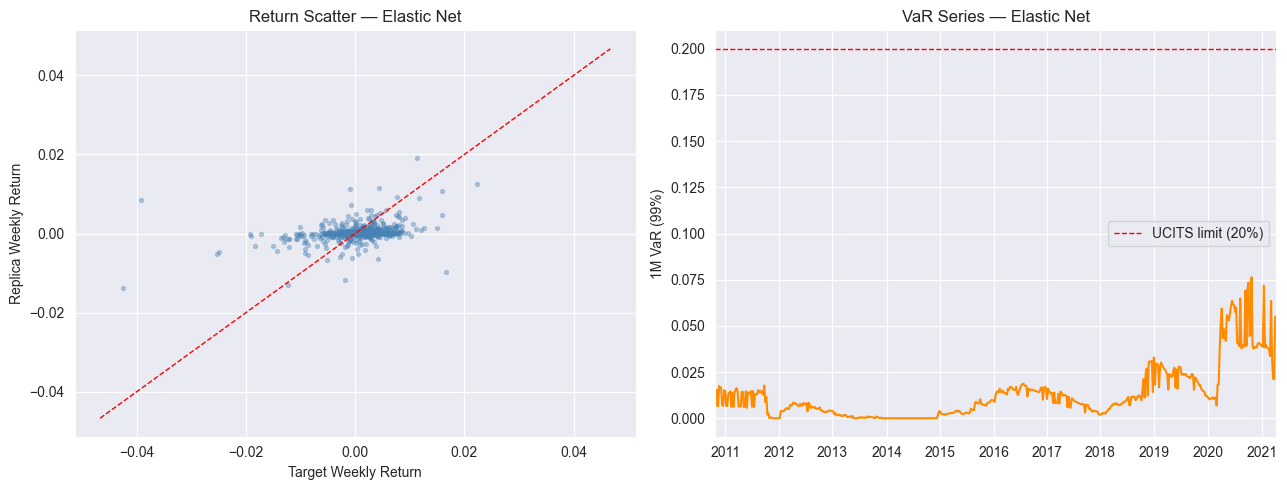

In [10]:
best_name = best_te_model
best_rep  = results[best_name]["replica_net"].loc[common_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Return scatter
axes[0].scatter(target_oos, best_rep, alpha=0.35, s=8, color="steelblue")
lim = max(abs(target_oos).max(), abs(best_rep).max()) * 1.1
axes[0].plot([-lim, lim], [-lim, lim], "r--", lw=1)
axes[0].set_xlabel("Target Weekly Return")
axes[0].set_ylabel("Replica Weekly Return")
axes[0].set_title(f"Return Scatter — {best_name}")

# VaR series
var_series = results[best_name]["var"].loc[common_idx].dropna()
var_series.plot(ax=axes[1], color="darkorange", lw=1.5)
axes[1].axhline(0.20, color="red", lw=1, linestyle="--", label="UCITS limit (20%)")
axes[1].set_title(f"VaR Series — {best_name}")
axes[1].set_ylabel("1M VaR (99%)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# Let's look at the actual VaR values your model calculated
ridge_var = results["Ridge"]["var"].dropna()

print(f"Average VaR: {ridge_var.mean() * 100:.2f}%")
print(f"Maximum VaR: {ridge_var.max() * 100:.2f}%")
print(f"Threshold:   {bt.var_threshold * 100:.2f}%")

Average VaR: 3.38%
Maximum VaR: 7.59%
Threshold:   20.00%
